In [1]:
import pandas as pd 
import numpy as np
import joblib
import time
import sklearn.metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier

## Dataset Prepare

In [2]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

## Weighted Voting Ensemble

In [3]:
train = pd.read_csv('./DS/train_shap_66.csv')
test = pd.read_csv('./DS/test_shap_66.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

In [4]:
# --- Load models ---
xgb_model = XGBClassifier()
xgb_model = joblib.load('./models/framework_xgb_best.pkl')
lgbm_model = LGBMClassifier()
lgbm_model = joblib.load('./models/framework_lgbm_best.pkl')
rf_model = RandomForestClassifier()
rf_model = joblib.load('./models/framework_rf_best.pkl')
et_model = ExtraTreesClassifier()
et_model = joblib.load('./models/framework_et_best.pkl')
cat_model = CatBoostClassifier()
cat_model = joblib.load('./models/framework_cat_best.pkl')

# --- Predict proba ---
xgb_preds = xgb_model.predict_proba(X_test)
cat_preds = cat_model.predict_proba(X_test)
rf_preds  = rf_model.predict_proba(X_test)
et_preds  = et_model.predict_proba(X_test)
lgbm_preds = lgbm_model.predict_proba(X_test)

# --- Predict labels ---
xgb_prediction = xgb_model.predict(X_test)
cat_prediction = cat_model.predict(X_test)
rf_prediction  = rf_model.predict(X_test)
et_prediction  = et_model.predict(X_test)
lgbm_prediction = lgbm_model.predict(X_test)

# --- Accuracy ---
xgb_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=xgb_prediction)
cat_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=cat_prediction)
rf_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
et_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=et_prediction)
lgbm_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=lgbm_prediction)

print("XGBoost Accuracy:", xgb_acc)
print("CatBoost Accuracy:", cat_acc)
print("RandomForest Accuracy:", rf_acc)
print("ExtraTrees Accuracy:", et_acc)
print("LightGBM Accuracy:", lgbm_acc)

# --- Macro-F1 ---
print("XGBoost Macro-F1:", f1_score(y_true=y_test, y_pred=xgb_prediction, average="macro"))
print("CatBoost Macro-F1:", f1_score(y_true=y_test, y_pred=cat_prediction, average="macro"))
print("RandomForest Macro-F1:", f1_score(y_true=y_test, y_pred=rf_prediction, average="macro"))
print("ExtraTrees Macro-F1:", f1_score(y_true=y_test, y_pred=et_prediction, average="macro"))
print("LightGBM Macro-F1:", f1_score(y_true=y_test, y_pred=lgbm_prediction, average="macro"))


XGBoost Accuracy: 0.8525641025641025
CatBoost Accuracy: 0.8357988165680473
RandomForest Accuracy: 0.854043392504931
ExtraTrees Accuracy: 0.8555226824457594
LightGBM Accuracy: 0.8451676528599605
XGBoost Macro-F1: 0.8476601943839882
CatBoost Macro-F1: 0.827278169145663
RandomForest Macro-F1: 0.8493029664497582
ExtraTrees Macro-F1: 0.851829172475585
LightGBM Macro-F1: 0.8405602047429012


In [5]:
import os, numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support

device = "cuda"
torch.manual_seed(42); np.random.seed(42)

# 0) Lấy dữ liệu từ train/test đã có sẵn trong session
X_full = train.drop(columns=["Label"]).values
y_full = train["Label"].astype(int).values
X_test = test.drop(columns=["Label"]).values
y_test = test["Label"].astype(int).values

num_classes  = int(max(y_full.max(), y_test.max())) + 1
num_features = X_full.shape[1]

# 1) Stratified split: train_in / val (15%)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(sss.split(X_full, y_full))
X_tr_in, y_tr_in = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]

# 2) Scaler: fit trên train_in, transform cho val & test
scaler = StandardScaler()
X_tr_in_sc = scaler.fit_transform(X_tr_in)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# 3) Class weights + sampler cân bằng
counts = np.bincount(y_tr_in, minlength=num_classes).astype(np.float32)
cls_w_np = (counts.sum() / (counts + 1e-9)); cls_w_np /= cls_w_np.mean()
cls_w    = torch.tensor(cls_w_np, dtype=torch.float32, device=device)
sample_w = cls_w_np[y_tr_in]
sampler  = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

# 4) DataLoaders
Xtr_t = torch.tensor(X_tr_in_sc, dtype=torch.float32)
ytr_t = torch.tensor(y_tr_in,    dtype=torch.long)
Xva_t = torch.tensor(X_val_sc,   dtype=torch.float32)
yva_t = torch.tensor(y_val,      dtype=torch.long)
Xte_t = torch.tensor(X_test_sc,  dtype=torch.float32)
yte_t = torch.tensor(y_test,     dtype=torch.long)

batch_size = 1024
train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, sampler=sampler, pin_memory=True)
val_loader   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=4096, shuffle=False, pin_memory=True)
test_loader  = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=4096, shuffle=False, pin_memory=True)

# 5) DNN ResNet-style
class ResidualBlock(nn.Module):
    def __init__(self, d_in, d_hid, p=0.3):
        super().__init__()
        self.lin1 = nn.Linear(d_in, d_hid)
        self.bn1  = nn.BatchNorm1d(d_hid)
        self.lin2 = nn.Linear(d_hid, d_in)
        self.bn2  = nn.BatchNorm1d(d_in)
        self.drop = nn.Dropout(p)
    def forward(self, x):
        h = self.drop(torch.relu(self.bn1(self.lin1(x))))
        h = self.bn2(self.lin2(h))
        return torch.relu(x + h)

class ResDNN(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(in_dim, 768), nn.BatchNorm1d(768), nn.ReLU(), nn.Dropout(0.35))
        self.block1 = ResidualBlock(768, 384, p=0.35)
        self.block2 = ResidualBlock(768, 384, p=0.35)
        self.block3 = ResidualBlock(768, 384, p=0.25)
        self.head   = nn.Linear(768, n_classes)
    def forward(self, x):
        h = self.stem(x)
        h = self.block1(h); h = self.block2(h); h = self.block3(h)
        return self.head(h)

model = ResDNN(num_features, num_classes).to(device)

# 6) Loss/optim/scheduler + mixup
criterion = nn.CrossEntropyLoss(weight=cls_w)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=2e-3, steps_per_epoch=len(train_loader), epochs=60
)

def mixup(x, y, alpha=0.2):
    if alpha <= 0: return x, y, 1.0, None
    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x_m = lam * x + (1 - lam) * x[perm]
    y_perm = y[perm]
    return x_m, y, lam, y_perm

# 7) Train với early-stopping theo Macro-F1 (VAL)
best_f1, best_state, wait, patience = -1.0, None, 0, 12
for epoch in range(60):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        xb_m, ya, lam, yb_ = mixup(xb, yb, alpha=0.2)
        logits = model(xb_m)
        loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb_) if yb_ is not None else criterion(logits, ya)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step()
        scheduler.step()

    # eval trên val
    model.eval()
    with torch.no_grad():
        logits_val = []
        for xb, _ in val_loader:
            logits_val.append(model(xb.to(device)).cpu())
        logits_val = torch.cat(logits_val, 0).numpy()
    pred_val = logits_val.argmax(1)
    f1_val = f1_score(y_val, pred_val, average='macro')

    if f1_val > best_f1:
        best_f1, wait = f1_val, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1
        if wait >= patience:
            print(f"DNN Early-stopped @ epoch {epoch+1}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# 8) Temperature scaling (tối ưu trên VAL), rồi đánh giá TEST
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

model.eval()
with torch.no_grad():
    logits_val = []
    for xb, _ in val_loader:
        logits_val.append(model(xb.to(device)).cpu())
    logits_val = torch.cat(logits_val, 0).numpy()

    logits_test = []
    for xb, _ in test_loader:
        logits_test.append(model(xb.to(device)).cpu())
    logits_test = torch.cat(logits_test, 0).numpy()

best_T, best_val_f1 = 1.0, -1.0
for T in np.linspace(0.5, 2.0, 16):
    p_val = softmax_np(logits_val / T)
    pred = p_val.argmax(1)
    f1 = f1_score(y_val, pred, average='macro')
    if f1 > best_val_f1:
        best_val_f1, best_T = f1, T

p_test_dnn = softmax_np(logits_test / best_T)
y_pred = p_test_dnn.argmax(1)

# 9) Đánh giá: Acc, Macro-F1, báo cáo, + Precision/Recall/F1/FPR per-class
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))

print(f"DNN ONLY (T={best_T:.2f}) — Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))

# Precision/Recall/F1 per class
labels = np.arange(num_classes)
prec, rec, f1c, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels, zero_division=0
)

# FPR per class từ confusion matrix
fpr_per_class = []
for i in labels:
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fpr_per_class.append(fpr_i)

# Macro metrics (Precision/Recall/FPR)
macro_precision = float(np.mean(prec))
macro_recall    = float(np.mean(rec))
try:
    macro_tpr, macro_fpr = calculate_macro_tpr_fpr(cm)
except NameError:
    macro_tpr, macro_fpr = macro_recall, float(np.mean(fpr_per_class))

print("\n==== Macro metrics ====")
print(f"Macro-Precision: {macro_precision:.4f}")
print(f"Macro-Recall/TPR: {macro_tpr:.4f}")
print(f"Macro-FPR: {macro_fpr:.4f}")

# Bảng per-class
per_class_df = pd.DataFrame({
    "class": labels,
    "precision": prec,
    "recall_TPR": rec,
    "f1": f1c,
    "FPR": fpr_per_class,
    "support": support,
}).round(4)

print("\n==== Per-class metrics (all classes) ====")
print(per_class_df)

DNN Early-stopped @ epoch 60
DNN ONLY (T=0.50) — Accuracy: 0.6928 | Macro-F1: 0.6835
Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       169
           1     0.8903    0.8166    0.8519       169
           2     0.7302    0.8166    0.7709       169
           3     0.4884    0.2485    0.3294       169
           4     0.4425    0.2959    0.3546       169
           5     0.6938    0.8580    0.7672       169
           6     0.4461    0.7101    0.5479       169
           7     0.6215    0.6509    0.6358       169
           8     0.7500    0.7633    0.7566       169
           9     0.5730    0.6036    0.5879       169
          10     0.6573    0.5562    0.6026       169
          11     1.0000    0.9941    0.9970       169

    accuracy                         0.6928      2028
   macro avg     0.6911    0.6928    0.6835      2028
weighted avg     0.6911    0.6928    0.6835      2028


==== Macro metrics ====


In [6]:
# === DNN 'predict_proba' & 'predict' style ===
dnn_preds = softmax_np(logits_test / best_T)           # (n_samples, n_classes)
dnn_prediction = dnn_preds.argmax(axis=1)              # (n_samples,)

# === Metrics giống 4 model kia ===
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

dnn_acc = accuracy_score(y_test, dnn_prediction)
dnn_macro_f1 = f1_score(y_test, dnn_prediction, average="macro", zero_division=0)

print("ResDNN Accuracy:", dnn_acc)
print("ResNN Macro-F1:", dnn_macro_f1)

# (tuỳ chọn) AUC macro OVR cho DNN
try:
    dnn_auc_macro_ovr = roc_auc_score(y_test, dnn_preds, multi_class='ovr', average='macro')
    print("ResDNN AUC (macro, OVR):", dnn_auc_macro_ovr)
except ValueError as e:
    print("ResDNN AUC không tính được:", e)


ResDNN Accuracy: 0.6928007889546351
ResNN Macro-F1: 0.6834911355712956
ResDNN AUC (macro, OVR): 0.9674611915167218


In [7]:
from scipy.optimize import minimize

def weighted_metric(weights, preds_list, y_true, metric='roc_auc'):
    # weights: [w1, w2, w3, w4. w5, w6]
    weights = np.array(weights)
    weights = np.clip(weights, 0, 1)
    weights = weights / np.sum(weights)
    combined = sum(w * p for w, p in zip(weights, preds_list))
    combined = combined / np.sum(combined, axis=1, keepdims=True)
    if metric == 'roc_auc':
        score = roc_auc_score(y_true, combined[:, 1])
        return -score  # minimize negative AUC

In [8]:
# ====== cấu hình ======
metric = "f1"      # "f1" hoặc "recall"
step = 0.05
N = int(round(1/step))

from sklearn.metrics import f1_score, recall_score, roc_auc_score
import numpy as np

# ====== danh sách proba của 6 mô hình (xgb, lgbm, rf, et, dnn, cat) ======
preds_list = [xgb_preds, lgbm_preds, rf_preds, et_preds, dnn_preds, cat_preds]

# Kiểm tra kích thước đầu vào
n_models = len(preds_list)
n_samples = preds_list[0].shape[0]
n_classes = preds_list[0].shape[1]
assert all(p.shape == (n_samples, n_classes) for p in preds_list), "preds_list shapes mismatch!"

best_score = -1.0
best_weights = None

# ====== search weights cho 6 mô hình: w1..w6, tổng = 1 ======
for i in range(N + 1):                                  # w1 = i/N
    for j in range(N + 1 - i):                          # w2 = j/N
        for k in range(N + 1 - i - j):                  # w3 = k/N
            for l in range(N + 1 - i - j - k):          # w4 = l/N
                for m in range(N + 1 - i - j - k - l):  # w5 = m/N
                    n = N - i - j - k - l - m           # w6 = n/N (>=0)
                    # Bỏ qua nếu âm (phòng hờ số học)
                    if n < 0:
                        continue

                    w = np.array([i, j, k, l, m, n], dtype=float) / N

                    # Ensemble proba
                    proba = np.zeros_like(preds_list[0], dtype=float)
                    for ww, pp in zip(w, preds_list):
                        proba += ww * pp

                    pred = proba.argmax(axis=1)
                    if metric == "f1":
                        score = f1_score(y_test, pred, average='macro', zero_division=0)
                    else:
                        score = recall_score(y_test, pred, average='macro', zero_division=0)

                    if score > best_score:
                        best_score = score
                        best_weights = tuple(w.tolist())

print("Best weights (xgb, lgbm, rf, et, dnn, cat):", best_weights, "sum =", sum(best_weights))
print(f"Best {metric} (macro):", best_score)

# ====== AUC macro OVR tại trọng số tốt nhất ======
w1, w2, w3, w4, w5, w6 = best_weights
proba_best = (w1*xgb_preds + w2*lgbm_preds + w3*rf_preds + w4*et_preds + w5*dnn_preds + w6*cat_preds)

try:
    auc_macro_ovr = roc_auc_score(y_test, proba_best, multi_class='ovr', average='macro')
    print("AUC (macro, OVR):", auc_macro_ovr)
except ValueError as e:
    # Lỗi nếu y_test fold chỉ có 1 lớp
    print("AUC không tính được:", e)


Best weights (xgb, lgbm, rf, et, dnn, cat): (0.05, 0.05, 0.15, 0.2, 0.4, 0.15) sum = 1.0
Best f1 (macro): 0.867423831277176
AUC (macro, OVR): 0.9894027986881877


In [9]:
avgs = (
    0.05 * xgb_preds
    + 0.05 * lgbm_preds
    + 0.15 * rf_preds
    + 0.2 * et_preds
    + 0.4 * dnn_preds
    + 0.15 * cat_preds
)

voting_prediction = avgs.argmax(axis=1)
voting_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=voting_prediction)
voting_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=voting_prediction)


# AUC-ROC calculation
# Convert y_test to binary indicator matrix if it isn't already
if y_test.ndim == 1 or y_test.shape[1] == 1:
    from sklearn.preprocessing import label_binarize
    y_test_binary = label_binarize(y_test, classes=range(avgs.shape[1]))
else:
    y_test_binary = y_test

# Compute the probabilities for each class
voting_probabilities = avgs / avgs.sum(axis=1, keepdims=True)  # Normalize probabilities

# Compute AUC-ROC for each label
auc_roc = sklearn.metrics.roc_auc_score(y_test_binary, voting_probabilities, average='macro', multi_class='ovr')

print("Voting report:")
print("Voting Accuracy:", voting_acc)
print("Voting Precision:", voting_precision)
print("Voting F1:", voting_f1)
print("Voting Recall:", voting_recall)
print("Voting AUC-ROC:", auc_roc)
print("Voting CM:\n", voting_cm)
voting_tpr, voting_fpr = calculate_macro_tpr_fpr(voting_cm)
print(f'Voting Macro-average TPR: {voting_tpr}')
print(f'Voting Macro-average FPR: {voting_fpr}')

Voting report:
Voting Accuracy: 0.8703155818540433
Voting Precision: 0.8682641675050001
Voting F1: 0.867423831277176
Voting Recall: 0.8703155818540435
Voting AUC-ROC: 0.9894027986881877
Voting CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   2 167   0   0   0   0   0   0   0   0   0]
 [  0   0   0 168   0   0   1   0   0   0   0   0]
 [  0   0   0   1 167   0   1   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   0   1   0 168   0   0   0   0   0]
 [  0   1  28   0   0   0   0  98  37   2   3   0]
 [  0   0   0   0   0   0   0  39 130   0   0   0]
 [  0   0   8   0   0   0   0   9   0 107  45   0]
 [  0   0   0   0   0   0   0   0   0  85  84   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
Voting Macro-average TPR: 0.8703155818540435
Voting Macro-average FPR: 0.011789492558723328


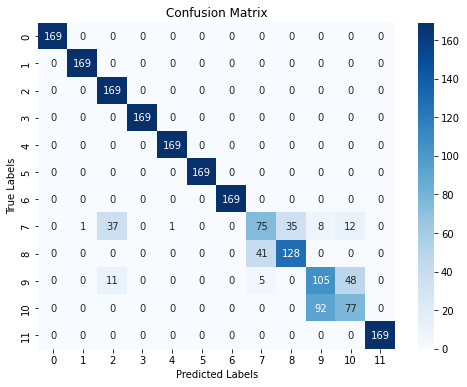

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(voting_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()